In [18]:
# ==========================================
# CHAPTER 1: NOTEBOOK THEME & SETUP
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

warnings.filterwarnings('ignore')

# Set standard layout style
sns.set_theme(style="whitegrid")

In [19]:
# ==========================================
# CHAPTER 2: PROBLEM STATEMENT
# ==========================================
print("Chapter 2: Predicting whether a patient has diabetes based on diagnostic measurements.")

Chapter 2: Predicting whether a patient has diabetes based on diagnostic measurements.


In [20]:
# ==========================================
# CHAPTER 3: DATASET OVERVIEW
# ==========================================
print("Chapter 3: Using the Pima Indians Diabetes Dataset via diabetes.csv.")

Chapter 3: Using the Pima Indians Diabetes Dataset via diabetes.csv.


In [21]:
# ==========================================
# CHAPTER 4: DATA UNDERSTANDING
# ==========================================
# 1. Load the dataset from the file verbatim
df = pd.read_csv('diabetes.csv')

# Basic commands to explore the data
print("--- Shape of Data ---")
print(df.shape)

print("\n--- First 5 Rows ---")
print(df.head())

print("\n--- Last 5 Rows ---")
print(df.tail())

print("\n--- Random 5 Sample Rows ---")
print(df.sample(5))

print("\n--- Columns List ---")
print(df.columns)

print("\n--- Data Types and Info ---")
df.info()

print("\n--- Summary Statistics ---")
print(df.describe())

--- Shape of Data ---
(768, 9)

--- First 5 Rows ---
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  

--- Last 5 Rows ---
     Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
763           10      101             76             48      180  32.9   
764            2      122             70             27        0  36.8   
765    

In [22]:
# ==========================================
# CHAPTER 5: DATA CLEANING
# ==========================================
print("\n--- Data Cleaning ---")

# Check for empty cells
print("Missing values count:")
print(df.isnull().sum())

# Check for duplicates
print("Duplicate rows count:", df.duplicated().sum())

# In this dataset, a value of 0 is an error for Glucose, BloodPressure, and BMI
# Let's replace 0 with the mean (average) value of each column
df['Glucose'] = df['Glucose'].replace(0, df['Glucose'].mean())
df['BloodPressure'] = df['BloodPressure'].replace(0, df['BloodPressure'].mean())
df['BMI'] = df['BMI'].replace(0, df['BMI'].mean())

print("Data Cleaning Finished!")


--- Data Cleaning ---
Missing values count:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64
Duplicate rows count: 0
Data Cleaning Finished!



--- Generating Plots ---


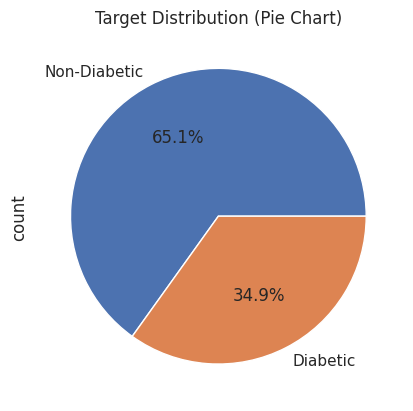

In [23]:
# ==========================================
# CHAPTER 6: EXPLORATORY DATA ANALYSIS (EDA)
# ==========================================
print("\n--- Generating Plots ---")

# 1. Pie Chart for Target
plt.figure()
df['Outcome'].value_counts().plot(kind='pie', autopct='%1.1f%%', labels=['Non-Diabetic', 'Diabetic'])
plt.title("Target Distribution (Pie Chart)")
plt.show()

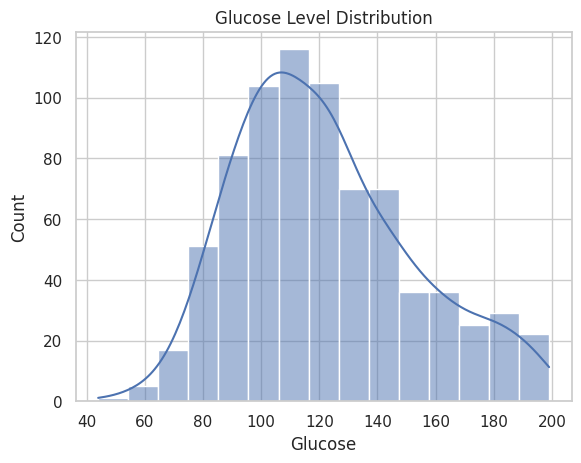

In [24]:
# 2. Histogram of Glucose
plt.figure()
sns.histplot(df['Glucose'], bins=15, kde=True)
plt.title("Glucose Level Distribution")
plt.show()

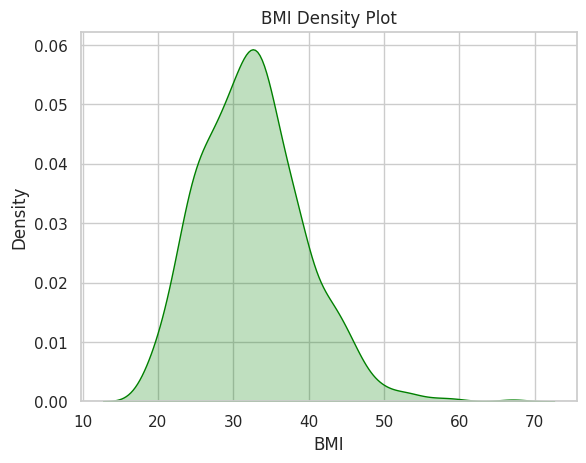

In [25]:
# 3. KDE Plot of BMI
plt.figure()
sns.kdeplot(df['BMI'], fill=True, color='green')
plt.title("BMI Density Plot")
plt.show()

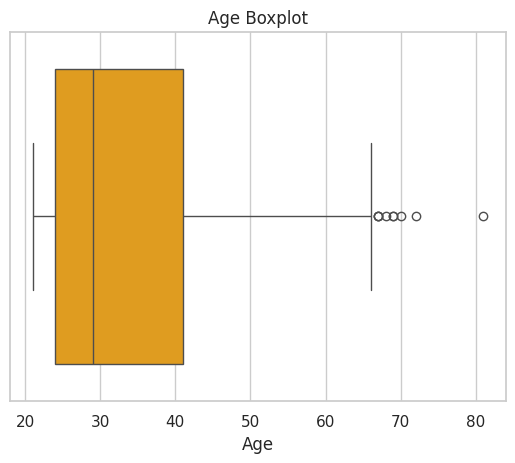

In [26]:
# 4. Boxplot of Age
plt.figure()
sns.boxplot(x=df['Age'], color='orange')
plt.title("Age Boxplot")
plt.show()

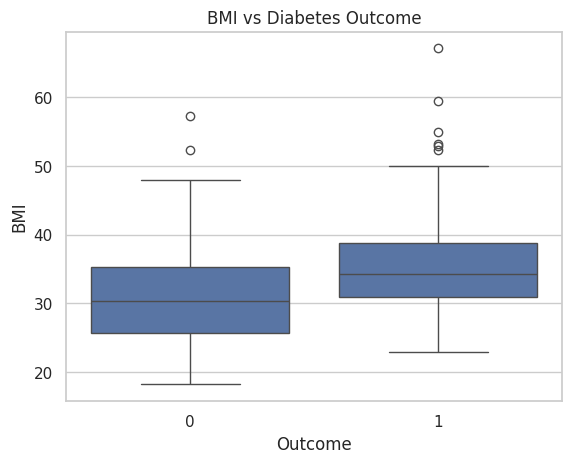

In [27]:
# 5. Boxplot: BMI vs Outcome
plt.figure()
sns.boxplot(data=df, x='Outcome', y='BMI')
plt.title("BMI vs Diabetes Outcome")
plt.show()



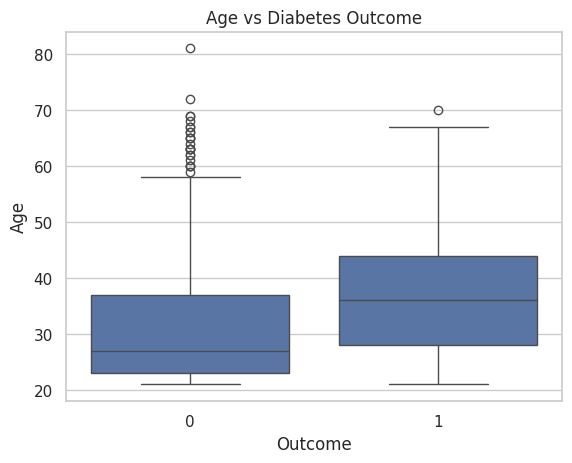

In [28]:
# 6. Boxplot: Age vs Outcome
plt.figure()
sns.boxplot(data=df, x='Outcome', y='Age')
plt.title("Age vs Diabetes Outcome")
plt.show()

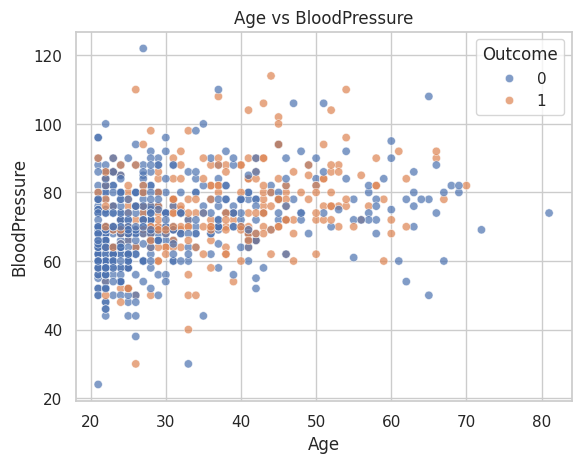

In [29]:
# 7. Scatter Plot: Age vs BloodPressure
plt.figure()
sns.scatterplot(data=df, x='Age', y='BloodPressure', hue='Outcome', alpha=0.7)
plt.title("Age vs BloodPressure")
plt.show()

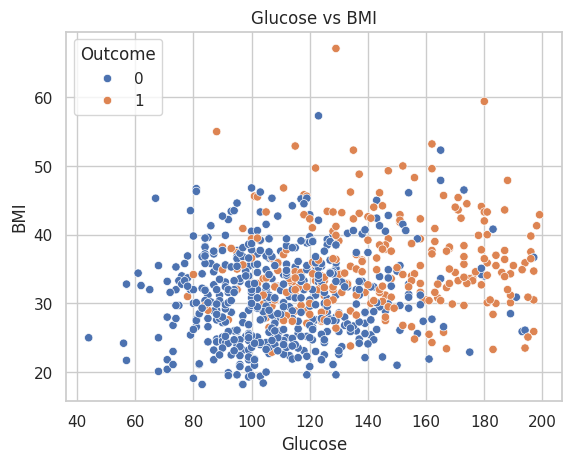

In [30]:
# 8. Scatter Plot: Glucose vs BMI
plt.figure()
sns.scatterplot(data=df, x='Glucose', y='BMI', hue='Outcome')
plt.title("Glucose vs BMI")
plt.show()

In [31]:
# ==========================================
# CHAPTER 7: DATA PREPROCESSING
# ==========================================
print("\n--- Data Preprocessing ---")

# 1. Split Features (X) and Target (y)
X = df.drop(columns=['Outcome'])
y = df['Outcome']

# 2. Train-Test Split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Scaling features (Making numerical values uniform for distance calculations)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Preprocessing Complete!")


--- Data Preprocessing ---
Preprocessing Complete!


In [32]:
# ==========================================
# CHAPTER 8 & 9: ML MODELS & EVALUATION
# ==========================================
print("\n--- Training and Evaluating Models ---")

# Initialize basic models
log_reg = LogisticRegression()
dec_tree = DecisionTreeClassifier(max_depth=5)
rand_forest = RandomForestClassifier(n_estimators=100)
knn = KNeighborsClassifier()
naive_bayes = GaussianNB()

# Train simple models
log_reg.fit(X_train_scaled, y_train)
dec_tree.fit(X_train, y_train)
rand_forest.fit(X_train, y_train)
knn.fit(X_train_scaled, y_train)
naive_bayes.fit(X_train, y_train)

# Generate Predictions
pred1 = log_reg.predict(X_test_scaled)
pred2 = dec_tree.predict(X_test)
pred3 = rand_forest.predict(X_test)
pred4 = knn.predict(X_test_scaled)
pred5 = naive_bayes.predict(X_test)

# Print out basic Accuracy for comparison
print("Logistic Regression Accuracy:", accuracy_score(y_test, pred1))
print("Decision Tree Accuracy:", accuracy_score(y_test, pred2))
print("Random Forest Accuracy:", accuracy_score(y_test, pred3))
print("KNN Accuracy:", accuracy_score(y_test, pred4))
print("Naive Bayes Accuracy:", accuracy_score(y_test, pred5))

print("\n--- Detailed Logistic Regression Metrics (Example) ---")
print("Confusion Matrix:\n", confusion_matrix(y_test, pred1))
print("\nClassification Report:\n", classification_report(y_test, pred1))


--- Training and Evaluating Models ---
Logistic Regression Accuracy: 0.7727272727272727
Decision Tree Accuracy: 0.7857142857142857
Random Forest Accuracy: 0.7402597402597403
KNN Accuracy: 0.7272727272727273
Naive Bayes Accuracy: 0.7597402597402597

--- Detailed Logistic Regression Metrics (Example) ---
Confusion Matrix:
 [[83 16]
 [19 36]]

Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.84      0.83        99
           1       0.69      0.65      0.67        55

    accuracy                           0.77       154
   macro avg       0.75      0.75      0.75       154
weighted avg       0.77      0.77      0.77       154



In [33]:
# ==========================================
# CHAPTER 10: CONCLUSION
# ==========================================
print("\nChapter 10: Notebook execution complete! Review the final accuracy scores to choose your best performing model for diabetes prediction.")


Chapter 10: Notebook execution complete! Review the final accuracy scores to choose your best performing model for diabetes prediction.
